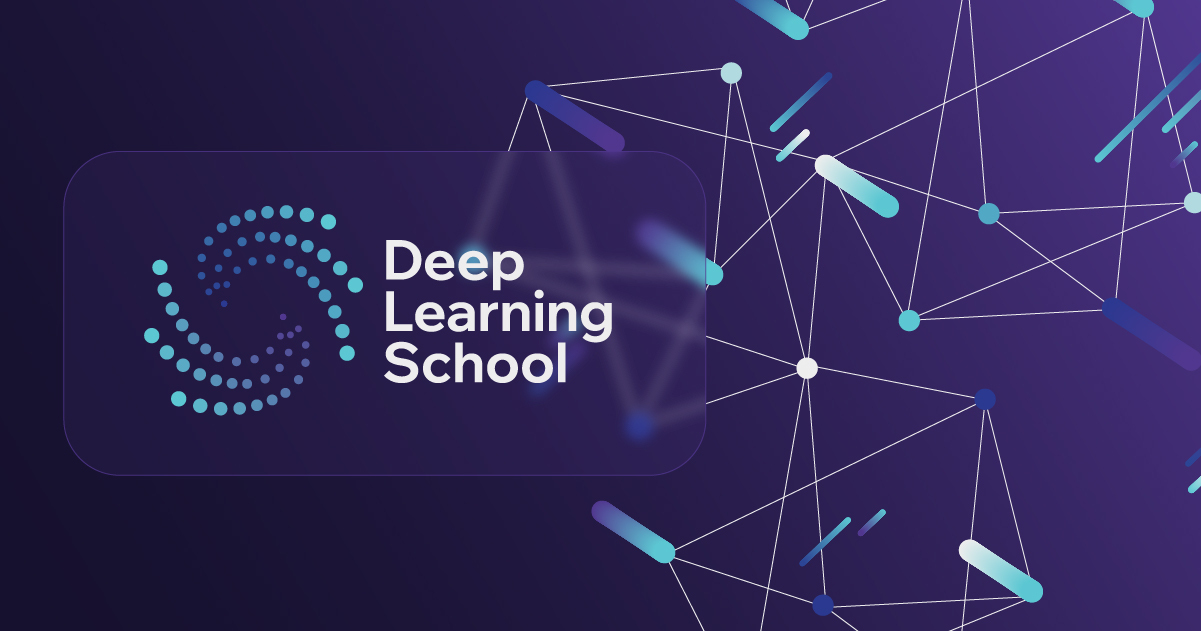

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Нейросетевая классификация текстов </b></h1>

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
!pip install -q datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [5]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [6]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [45]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch)
    labels = torch.LongTensor([x['label'] for x in input_batch])

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [89]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 128
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size, 
    num_workers=2, persistent_workers=True)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size, 
    num_workers=2, persistent_workers=True)

### Функции для обучения и валидации

In [106]:
def evaluate(model, test_dataloader, device):
  """Валидация модели с визуализацией прогресса."""
  model.eval()
  correct = 0
  total = 0

  val_pbar = tqdm(test_dataloader, desc="Validating", leave=False)

  with torch.no_grad():
    for batch in val_pbar:
      inputs = batch["input_ids"].to(device)
      labels = batch["label"].to(device)

      logits = model(inputs)
      preds = torch.argmax(logits, dim=-1)

      correct += (preds == labels).sum().item()
      total += labels.size(0)

      val_pbar.set_postfix({"cur_acc": f"{correct / total:.4f}"})

  return correct / total if total > 0 else 0.0

In [112]:
def train_one_model(
    model,
    train_dataloader,
    test_dataloader,
    num_epoch,
    aggregation_type="",
    criterion=None,
    optimizer=None,
    device="cuda",
):
  history = {"train_loss": [], "train_acc": [], "test_acc": []}

  if criterion is None:
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind["<pad>"])
  if optimizer is None:
    optimizer = torch.optim.Adam(model.parameters())

  for epoch in range(1, num_epoch + 1):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    desc_label = (
        f"Epoch {epoch}/{num_epoch} [{aggregation_type}]"
        if aggregation_type
        else f"Epoch {epoch}/{num_epoch}"
    )

    train_pbar = tqdm(
        train_dataloader, desc=f"{desc_label} [Train]", leave=False
    )

    for batch in train_pbar:
      inputs = batch["input_ids"].to(device)
      labels = batch["label"].to(device)

      optimizer.zero_grad()
      logits = model(inputs)
      loss = criterion(logits, labels)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
      optimizer.step()

      batch_size = labels.size(0)
      running_loss += loss.item() * batch_size

      preds = torch.argmax(logits, dim=-1)
      train_correct += (preds == labels).sum().item()
      train_total += batch_size

      train_pbar.set_postfix({
          "loss": f"{running_loss / train_total:.4f}",
          "train_acc": f"{train_correct / train_total:.4f}",
      })

    train_pbar.close()

    epoch_train_loss = running_loss / train_total
    epoch_train_acc = train_correct / train_total

    epoch_test_acc = evaluate(model, test_dataloader, device)

    summary_bar = tqdm(
        total=len(train_dataloader),
        desc=desc_label,
        leave=True,
        bar_format="{desc}: 100%|{bar}| {n_fmt}/{total_fmt} [{postfix}]",
    )
    summary_bar.n = len(train_dataloader)
    summary_bar.set_postfix({
        "loss": f"{epoch_train_loss:.4f}",
        "train_acc": f"{epoch_train_acc:.4f}",
        "test_acc": f"{epoch_test_acc:.4f}",
    })
    summary_bar.close()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["test_acc"].append(epoch_test_acc)

  return history, model

In [108]:
def train_models(
    model_type,
    num_epoch,
    aggregation_types,
    train_dataloader,
    test_dataloader,
    num_classes,
    parallel=False,
    n_rnn_layers=1,
    num_embeddings=len(vocab),
    embedding_dim=300,
    device="cuda",
):
  all_history = {}
  all_models = []

  for aggregation_type in aggregation_types:
    print(f"\n{'='*20} Starting training for {aggregation_type} {'='*20}")

    model = model_type(
        num_embeddings=num_embeddings,
        embedding_dim=embedding_dim,
        num_classes=num_classes,
        n_rnn_layers=n_rnn_layers,
        aggregation_type=aggregation_type,
    ).to(device)

    if parallel and torch.cuda.device_count() > 1:
      print(f"Training on {torch.cuda.device_count()} GPUs")
      model = nn.DataParallel(model)

    cur_hist, model = train_one_model(
        model=model,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        num_epoch=num_epoch,
        aggregation_type=aggregation_type,
        device=device,
    )

    all_history[aggregation_type] = cur_hist
    all_models.append(model)

  return all_history, all_models

In [109]:
def plot_training_history(history):
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  colors = {'max': 'royalblue', 'mean': 'darkorange'}

  for agg_type, metrics in history.items():
    epochs = range(1, len(metrics['train_loss']) + 1)
    color = colors.get(agg_type, None)

    axes[0].plot(
        epochs,
        metrics['train_loss'],
        marker='o',
        linewidth=2,
        color=color,
        label=f'{agg_type} (train loss)',
    )

  axes[0].set_title('Training Loss по эпохам', fontsize=14)
  axes[0].set_xlabel('Эпоха', fontsize=12)
  axes[0].set_ylabel('Loss', fontsize=12)
  axes[0].set_xticks(epochs)
  axes[0].grid(True, linestyle='--', alpha=0.5)
  axes[0].legend(fontsize=10)

  for agg_type, metrics in history.items():
    epochs = range(1, len(metrics['train_acc']) + 1)
    color = colors.get(agg_type, None)

    axes[1].plot(
        epochs,
        metrics['train_acc'],
        marker='o',
        linestyle='-',
        linewidth=2,
        color=color,
        label=f'{agg_type} (train acc)',
    )

    axes[1].plot(
        epochs,
        metrics['test_acc'],
        marker='s',
        linestyle='--',
        linewidth=2,
        color=color,
        alpha=0.8,
        label=f'{agg_type} (test acc)',
    )

  axes[1].set_title('Accuracy (Train vs Test) по эпохам', fontsize=14)
  axes[1].set_xlabel('Эпоха', fontsize=12)
  axes[1].set_ylabel('Accuracy', fontsize=12)
  axes[1].set_xticks(epochs)
  axes[1].grid(True, linestyle='--', alpha=0.5)
  axes[1].legend(fontsize=10)

  plt.tight_layout()
  plt.show()

In [110]:
def evaluate_final(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """
    model.eval()
    model = model.cpu()

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'].cpu())
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

### Base model

In [50]:
class VanillaRNN(nn.Module):
    def __init__(self, num_classes, n_rnn_layers=1, num_embeddings=len(vocab), embedding_dim=300, aggregation_type="max"):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=embedding_dim, 
                          batch_first=True, num_layers=n_rnn_layers)
        self.linear = nn.Linear(embedding_dim, embedding_dim)
        self.out_layer = nn.Linear(embedding_dim, num_classes)
        
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, x):
        embed = self.embedding(x)

        output, _ = self.rnn(embed)

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.tanh(output)))

        return self.out_layer(self.tanh(output))

In [54]:
history = train_models(
    model_type=VanillaRNN,
    num_epoch=5,
    aggregation_types=["max", "mean"],
    train_dataloader=train_dataloader,
    test_dataloader=eval_dataloader,
    num_classes=4,
    parallel=True,
    n_rnn_layers=1,
    num_embeddings=len(vocab),
    embedding_dim=300,
    device='cuda'
)


==================== Starting training for max ====================
Training on 2 GPUs


Epoch 1/5 [max]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/5 [max]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3/5 [max]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 4/5 [max]:   0%|          | 0/1875 [00:00<?, ?it/s]

...

Epoch 1/5 [mean]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/5 [mean]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3/5 [mean]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 4/5 [mean]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 5/5 [mean]:   0%|          | 0/1875 [00:00<?, ?it/s]

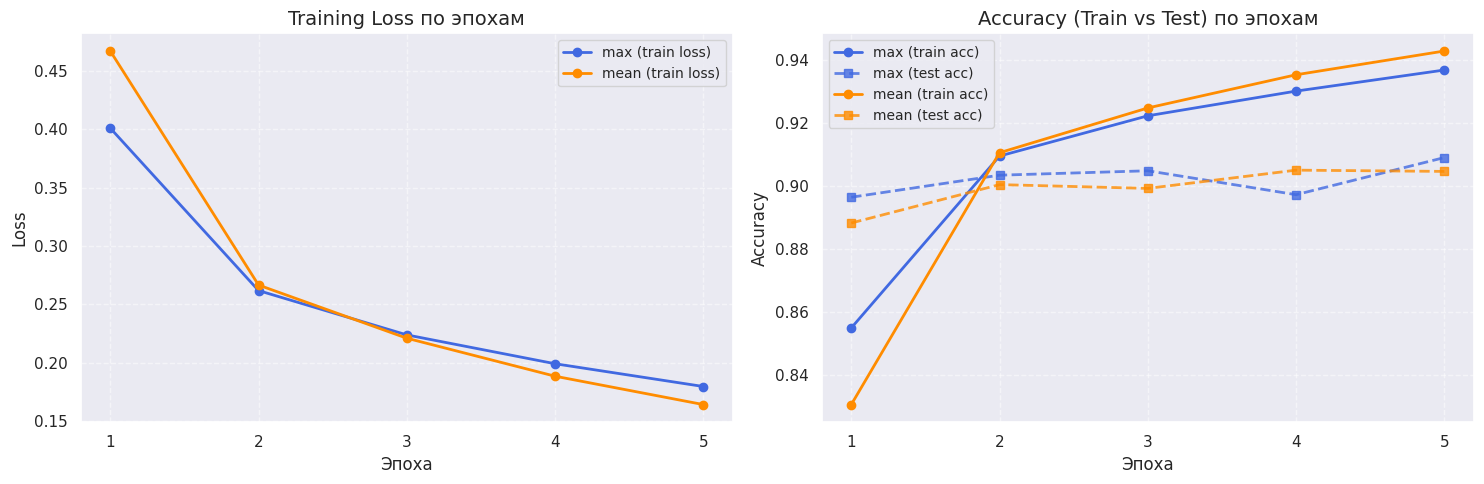

In [57]:
plot_training_history(history)

Здесь я выявил 2 недоработки своих функций  для обучения модели: 
1) Во время обучения выводится скор только для тренировочных данных, а хотелось бы еще и для тестовых
2) Я не вернул модели после тренировки, чтобы посчитать финальный скор на валидационных данных

Не буду писать еще раз многострочные функции, просто изменю те, что выше и дальше в выводах обучения будет заметна разница. Здесь по обучению можно сказать, что mean обогнал max на трейне, но у обоих примерно 0.9 на тесте

In [62]:
history['max']['test_acc'][-1], history['mean']['test_acc'][-1]

(0.909, 0.9046)

### BiRNN + BS 64 -> 128

In [76]:
class BiRNN(nn.Module):
    def __init__(self, num_classes, n_rnn_layers=1, num_embeddings=len(vocab), embedding_dim=300, aggregation_type="max"):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=embedding_dim, 
                          batch_first=True, num_layers=n_rnn_layers, bidirectional=True)
        self.linear = nn.Linear(2 * embedding_dim, embedding_dim)
        self.out_layer = nn.Linear(embedding_dim, num_classes)
        
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, x):
        embed = self.embedding(x)

        output, _ = self.rnn(embed)

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.tanh(output)))

        return self.out_layer(self.tanh(output))

In [77]:
history, models = train_models(
    model_type=BiRNN,
    num_epoch=5,
    aggregation_types=["max", "mean"],
    train_dataloader=train_dataloader,
    test_dataloader=eval_dataloader,
    num_classes=4,
    parallel=True,
    n_rnn_layers=1,
    num_embeddings=len(vocab),
    embedding_dim=300,
    device='cuda'
)


==================== Starting training for max ====================
Training on 2 GPUs


Epoch 1/5 [max] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/5 [max]: 100%|          | 0/938 []

Epoch 2/5 [max] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 4/5 [mean]: 100%|          | 0/938 []

Epoch 5/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 5/5 [mean]: 100%|          | 0/938 []

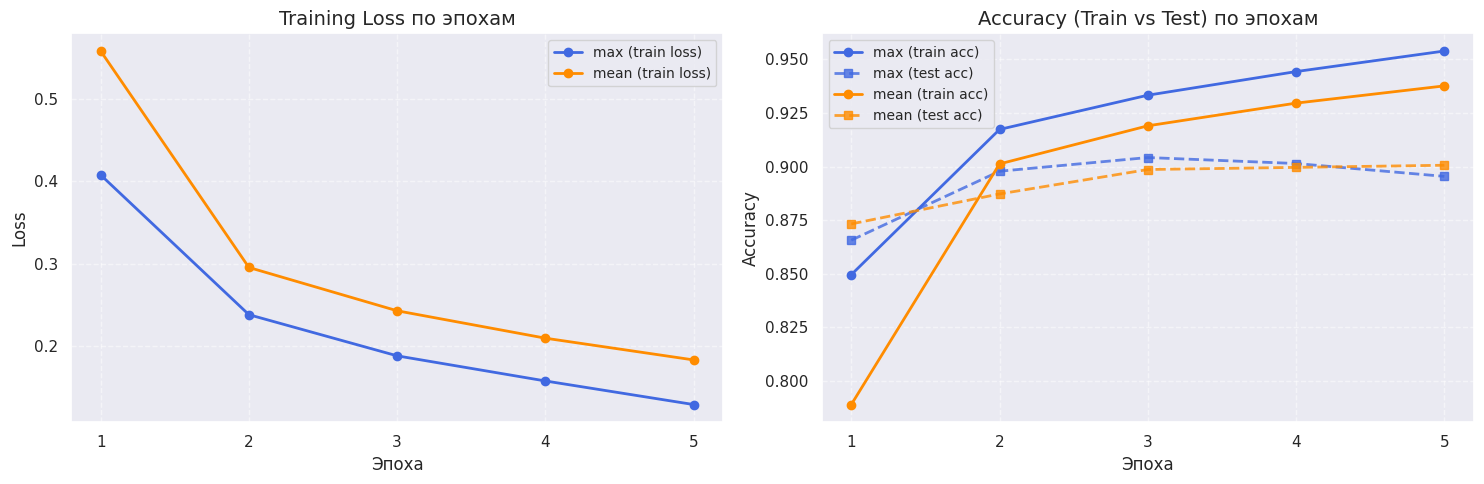

In [78]:
plot_training_history(history)

In [88]:
for m, t in zip(models, ['max', 'mean']):
    print(f"{t} val asore: {evaluate_final(m.module, eval_dataloader)}")

max val asore: 0.8953999876976013
mean val asore: 0.900600016117096


И опять mean обходит max. Также можно заметить, что модели как будто не хватает параметров, чтобы дообучиться. попробуем использовать 5 слоев birnn, увеличив число параметров на 2 млн

In [90]:
!pip install -q torchinfo

In [95]:
import torchinfo
torchinfo.summary(models[0].module, (128, 75), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
BiRNN                                    [128, 4]                  --
├─Embedding: 1-1                         [128, 75, 300]            3,552,600
├─RNN: 1-2                               [128, 75, 600]            361,200
├─Tanh: 1-3                              [128, 600]                --
├─Linear: 1-4                            [128, 300]                180,300
├─Dropout: 1-5                           [128, 300]                --
├─Tanh: 1-6                              [128, 300]                --
├─Linear: 1-7                            [128, 4]                  1,204
Total params: 4,095,304
Trainable params: 4,095,304
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.95
Input size (MB): 0.08
Forward/backward pass size (MB): 69.43
Params size (MB): 16.38
Estimated Total Size (MB): 85.89

### BiRNN 5 RNN-слоев

In [101]:
test_m = BiRNN(num_classes=4, n_rnn_layers=5)
torchinfo.summary(test_m, (128, 75), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
BiRNN                                    [128, 4]                  --
├─Embedding: 1-1                         [128, 75, 300]            3,552,600
├─RNN: 1-2                               [128, 75, 600]            2,526,000
├─Tanh: 1-3                              [128, 600]                --
├─Linear: 1-4                            [128, 300]                180,300
├─Dropout: 1-5                           [128, 300]                --
├─Tanh: 1-6                              [128, 300]                --
├─Linear: 1-7                            [128, 4]                  1,204
Total params: 6,260,104
Trainable params: 6,260,104
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 24.73
Input size (MB): 0.08
Forward/backward pass size (MB): 69.43
Params size (MB): 25.04
Estimated Total Size (MB): 94.55

In [102]:
history, models = train_models(
    model_type=BiRNN,
    num_epoch=5,
    aggregation_types=["max", "mean"],
    train_dataloader=train_dataloader,
    test_dataloader=eval_dataloader,
    num_classes=4,
    parallel=True,
    n_rnn_layers=5,
    num_embeddings=len(vocab),
    embedding_dim=300,
    device='cuda'
)


==================== Starting training for max ====================
Training on 2 GPUs


Epoch 1/5 [max] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/5 [max]: 100%|          | 0/938 []

Epoch 2/5 [max] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 4/5 [mean]: 100%|          | 0/938 []

Epoch 5/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 5/5 [mean]: 100%|          | 0/938 []

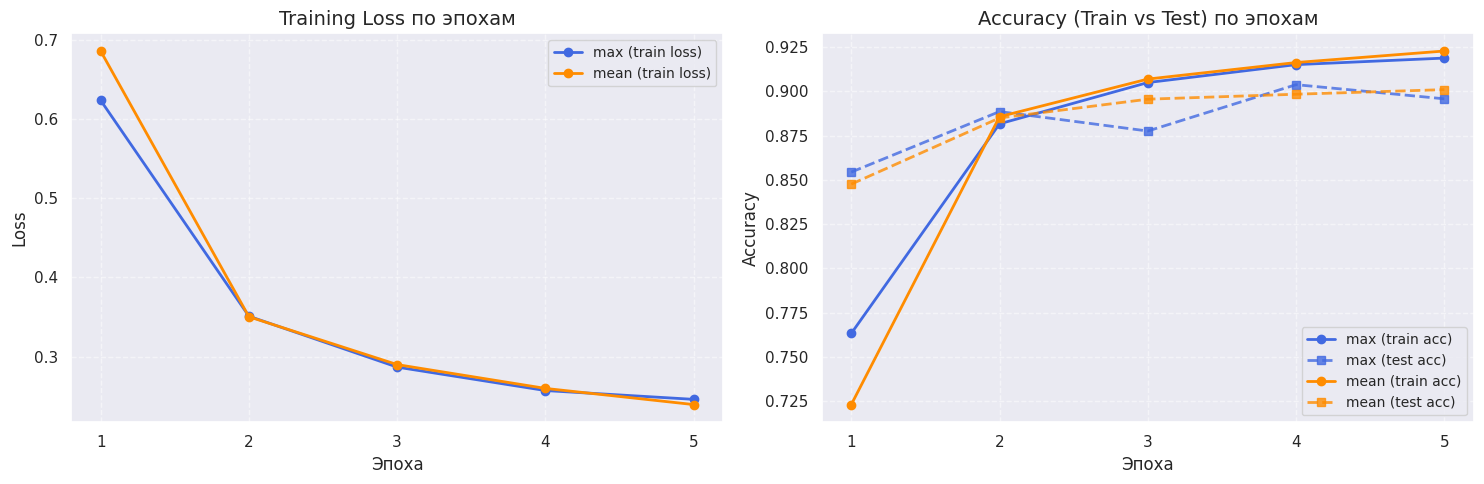

In [103]:
plot_training_history(history)

In [104]:
for m, t in zip(models, ['max', 'mean']):
    print(f"{t} val asore: {evaluate_final(m.module, eval_dataloader)}")

max val asore: 0.895799994468689
mean val asore: 0.9010000228881836


Я поставил слишком большое количество слоев rnn => пришел к затуханию градиентов и переобучению.Качество улучшить не удалось. Теперь буду ставить до 3 слоев при 5 эпохах обучения и использовать архитектуры с гейтами, у которых меньше влияние затухания

Для предотвращения взрыва градиентов я добавлю gradient clipping в функцию обучения

### BiGRU + gradient_clipping

Посмотрим на стандартные нормы градиентов для нашего датасета, чтобы выставить оптимальную норму при обучении

In [111]:
total_norm = torch.nn.utils.clip_grad_norm_(models[0].module.parameters(), max_norm=float('inf'))
print(total_norm.item())

1.3179081678390503


Значит поставлю ограничение на норму 3 (тк это эвристически хорошее значение + немного больше характерного для нашего датасета значения, чтобы аномалии обрезались)

Здесь обучу только усреднение выходов рекуррентного слоя, чтобы сэкономить время, тк он уже 3 раза показывает себя лучше максимального значения

In [119]:
class BiGRU(nn.Module):
    def __init__(self, num_classes, n_rnn_layers=1, num_embeddings=len(vocab), embedding_dim=300, aggregation_type="max"):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)
        self.rnn = nn.GRU(input_size=embedding_dim, hidden_size=embedding_dim, 
                          batch_first=True, num_layers=n_rnn_layers, 
                          bidirectional=True, dropout=0.2)
        self.linear = nn.Linear(2 * embedding_dim, embedding_dim)
        self.out_layer = nn.Linear(embedding_dim, num_classes)
        
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, x):
        embed = self.embedding(x)

        output, _ = self.rnn(embed)

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.tanh(output)))

        return self.out_layer(self.tanh(output))

In [120]:
history, models = train_models(
    model_type=BiGRU,
    num_epoch=5,
    aggregation_types=["mean"],
    train_dataloader=train_dataloader,
    test_dataloader=eval_dataloader,
    num_classes=4,
    parallel=True,
    n_rnn_layers=2,
    num_embeddings=len(vocab),
    embedding_dim=300,
    device='cuda'
)


==================== Starting training for mean ====================
Training on 2 GPUs


Epoch 1/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/5 [mean]: 100%|          | 0/938 []

Epoch 2/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 4/5 [mean]: 100%|          | 0/938 []

Epoch 5/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 5/5 [mean]: 100%|          | 0/938 []

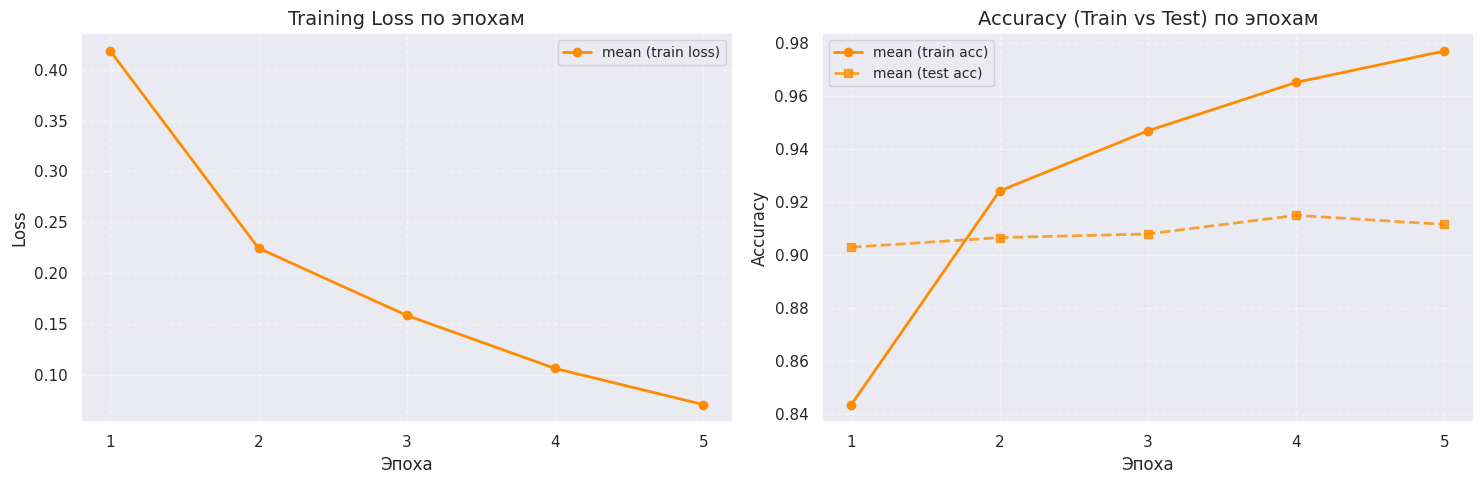

In [121]:
plot_training_history(history)

In [122]:
for m, t in zip(models, ['mean']):
    print(f"{t} val asore: {evaluate_final(m.module, eval_dataloader)}")

mean val asore: 0.9114000201225281


In [123]:
torchinfo.summary(models[0].module, (128, 75), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
BiGRU                                    [128, 4]                  --
├─Embedding: 1-1                         [128, 75, 300]            3,552,600
├─GRU: 1-2                               [128, 75, 600]            2,707,200
├─Tanh: 1-3                              [128, 600]                --
├─Linear: 1-4                            [128, 300]                180,300
├─Dropout: 1-5                           [128, 300]                --
├─Tanh: 1-6                              [128, 300]                --
├─Linear: 1-7                            [128, 4]                  1,204
Total params: 6,441,304
Trainable params: 6,441,304
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 26.47
Input size (MB): 0.08
Forward/backward pass size (MB): 69.43
Params size (MB): 25.77
Estimated Total Size (MB): 95.27

Как видно по графику скора, модель очень сильно переобучилась, хоть и скор на тесте все равно вырос довольно сильно

### BiLSTM для сравнения с BiGRU

In [124]:
class BiLSTM(nn.Module):
    def __init__(self, num_classes, n_rnn_layers=1, num_embeddings=len(vocab), embedding_dim=300, aggregation_type="max"):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)
        self.rnn = nn.LSTM(input_size=embedding_dim, hidden_size=embedding_dim, 
                          batch_first=True, num_layers=n_rnn_layers, 
                          bidirectional=True, dropout=0.2)
        self.linear = nn.Linear(2 * embedding_dim, embedding_dim)
        self.out_layer = nn.Linear(embedding_dim, num_classes)
        
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, x):
        embed = self.embedding(x)

        output, _ = self.rnn(embed)

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.tanh(output)))

        return self.out_layer(self.tanh(output))

In [125]:
history, models = train_models(
    model_type=BiLSTM,
    num_epoch=5,
    aggregation_types=["mean"],
    train_dataloader=train_dataloader,
    test_dataloader=eval_dataloader,
    num_classes=4,
    parallel=True,
    n_rnn_layers=2,
    num_embeddings=len(vocab),
    embedding_dim=300,
    device='cuda'
)


==================== Starting training for mean ====================
Training on 2 GPUs


Epoch 1/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/5 [mean]: 100%|          | 0/938 []

Epoch 2/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 4/5 [mean]: 100%|          | 0/938 []

Epoch 5/5 [mean] [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 5/5 [mean]: 100%|          | 0/938 []

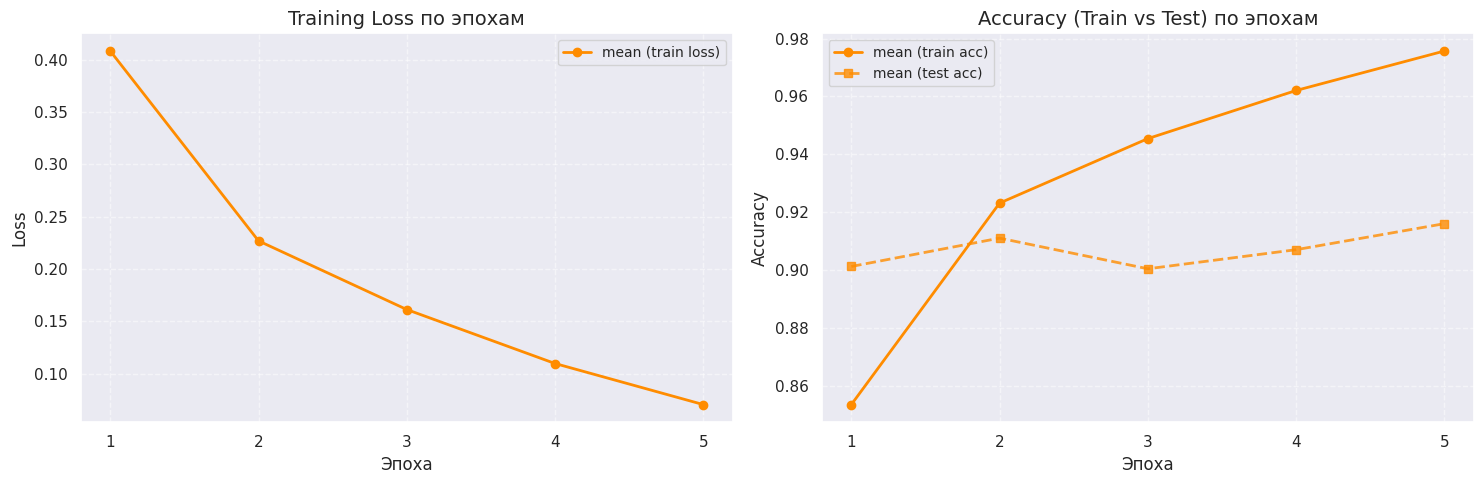

In [126]:
plot_training_history(history)

In [127]:
for m, t in zip(models, ['mean']):
    print(f"{t} val asore: {evaluate_final(m.module, eval_dataloader)}")

mean val asore: 0.9160000085830688


In [128]:
torchinfo.summary(models[0].module, (128, 75), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
BiLSTM                                   [128, 4]                  --
├─Embedding: 1-1                         [128, 75, 300]            3,552,600
├─LSTM: 1-2                              [128, 75, 600]            3,609,600
├─Tanh: 1-3                              [128, 600]                --
├─Linear: 1-4                            [128, 300]                180,300
├─Dropout: 1-5                           [128, 300]                --
├─Tanh: 1-6                              [128, 300]                --
├─Linear: 1-7                            [128, 4]                  1,204
Total params: 7,343,704
Trainable params: 7,343,704
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 35.13
Input size (MB): 0.08
Forward/backward pass size (MB): 69.43
Params size (MB): 29.37
Estimated Total Size (MB): 98.88

Здесь тоже заметно переобучение, с этим надо что-то делать

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [ ]:
def evaluate_final(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!